Methodology : 
- define global parameters
- presenting the beta and gamma heatmaps
- define the regime : R0 less than 1 or not (so define N)
- compute R0
- condition to be checked : min(β/γ) ≤ R0 ≤ max(β/γ) (maybe see again if the formula would be different with the mass-action mechanism)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# setup
import numpy as np
import sys
from pathlib import Path
import seaborn as sb

# Add parent directory to path to import local modules
sys.path.insert(0, str(Path.cwd().parent))

from src.core.SEIRSParameters import SEIRSParameters


Global parameters definition

| Diffusion Rate | Value | Source |
| :--- | :--- | :--- |
| $d_S$ | 0.1 | Wang, J., et al. (2012). Spatiotemporal patterns of a SEIRS epidemic model with constant recruitment and delay. |
| $d_E$ | 0.1 | Wang, J., et al. (2012). Spatiotemporal patterns of a SEIRS epidemic model with constant recruitment and delay. |
| $d_I$ | 0.01 | Wang, J., et al. (2012). Spatiotemporal patterns of a SEIRS epidemic model with constant recruitment and delay. |
| $d_R$ | 0.1 | Wang, J., et al. (2012). Spatiotemporal patterns of a SEIRS epidemic model with constant recruitment and delay. |

In [3]:
n = 10 # grid size (number of nodes in each dimension); we'll use a smaller value for quick implementtion

# diffusion rates
DS = DE = DR = 0.1
DI = 0.01

ALPHA = SIGMA = 0.1
BETA_0 = 0.21
GAMMA_0 = 0.21

POPULATION_DENSITY = 1.0

baseParams = SEIRSParameters(
    dS=DS,
    dE=DE,
    dI=DI,
    dR=DR,
    N=POPULATION_DENSITY,
    grid_size=n,
    alpha=ALPHA,
    sigma=SIGMA,
    beta_0=BETA_0,
    gamma_0=GAMMA_0
)

Plotting the beta and gamma maps

In [4]:
# Gaussian parameters
R_GAMMA = 0.1 # radius/width
R_BETA = 0.1
C_GAMMA = (0.25, 0.25) # center
C_BETA = (0.75, 0.75)

In [5]:
beta_field = baseParams.beta_field(mu=C_BETA, sigma=R_BETA)
gamma_field = baseParams.gamma_field(mu=C_GAMMA, sigma=R_GAMMA)

In [6]:
# 2D heatmap helper for spatial fields
TITLE_KW   = dict(fontsize=11, fontweight='bold', color='#000000', pad=10)    
LABEL_KW   = dict(fontsize=9,  color='#000000')
TICK_KW    = dict(colors='#000000', labelsize=8)

def plot_heatmap(field, title='', xlabel='x', ylabel='y', cmap='viridis', cbar_label=None, center=None, radius=None, circle_edgecolor='#ff3333'):
    """Plot a 2D spatial field using seaborn/matplotlib with publication-ready styling.

    Parameters
    - field: 2D array (ny, nx)
    - title, xlabel, ylabel: labels
    - cmap: colormap
    - cbar_label: colorbar label (if None, will use title)
    - center: tuple (x, y) in normalized coordinates [0,1] to mark with a dot and circle
    - radius: float in normalized coordinates [0,1] for the circle radius
    - circle_edgecolor: color for the circle/point marker
    """
    # Local import of matplotlib to avoid top-level matplotlib import
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches

    # Use seaborn theme for publication-ready plots
    sb.set_theme(style='white', context='talk', rc={'axes.edgecolor': '#333333', 'figure.dpi': 100})

    field = np.asarray(field)
    ny, nx = field.shape

    fig, ax = plt.subplots(figsize=(7, 6), dpi=100)
    fig.patch.set_facecolor('#ffffff')
    ax.set_facecolor('#ffffff')

    # Show the field in normalized coordinates [0,1] so centers/radii map directly
    im = ax.imshow(field, cmap=cmap, origin='lower', extent=(0.0, 1.0, 0.0, 1.0), aspect='equal', interpolation='nearest')

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label or title, **LABEL_KW)
    cbar.ax.yaxis.set_tick_params(**TICK_KW)

    # Graduations / ticks: show 0.0, 0.25, 0.5, 0.75, 1.0
    major_ticks = np.linspace(0.0, 1.0, 5)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticklabels([f"{t:.2f}" for t in major_ticks], **LABEL_KW)
    ax.set_yticklabels([f"{t:.2f}" for t in major_ticks], **LABEL_KW)
    ax.grid(which='major', color='#dddddd', linestyle='--', linewidth=0.8, alpha=0.8)

    # Apply labels and styling
    ax.set_title(title, loc='center', **TITLE_KW)
    ax.set_xlabel(xlabel, **LABEL_KW)
    ax.set_ylabel(ylabel, **LABEL_KW)
    ax.tick_params(axis='both', **TICK_KW)

    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

    # Draw center and circle if provided (center in normalized [0,1] coordinates)
    if center is not None and radius is not None:
        try:
            cx, cy = float(center[0]), float(center[1])
            r = float(radius)
            # Draw circle (not filled)
            circle = patches.Circle((cx, cy), r, fill=False, edgecolor=circle_edgecolor, linewidth=2, alpha=0.9)
            ax.add_patch(circle)
            # Draw center point
            ax.plot(cx, cy, marker='o', color=circle_edgecolor, markersize=6)
        except Exception:
            pass

    return fig, ax, im


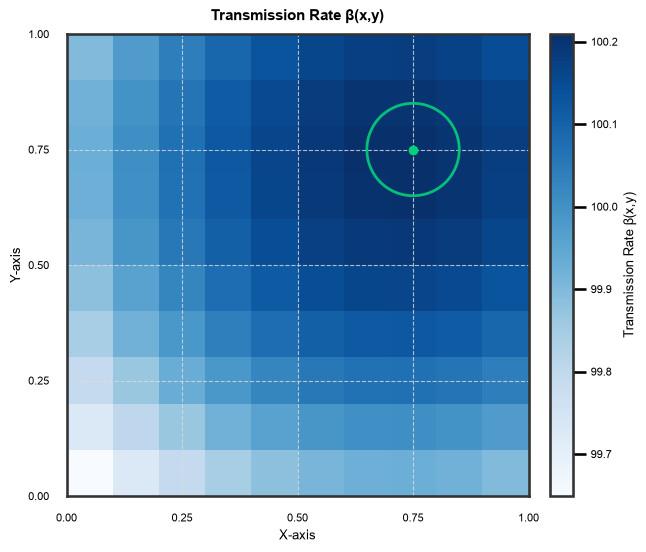

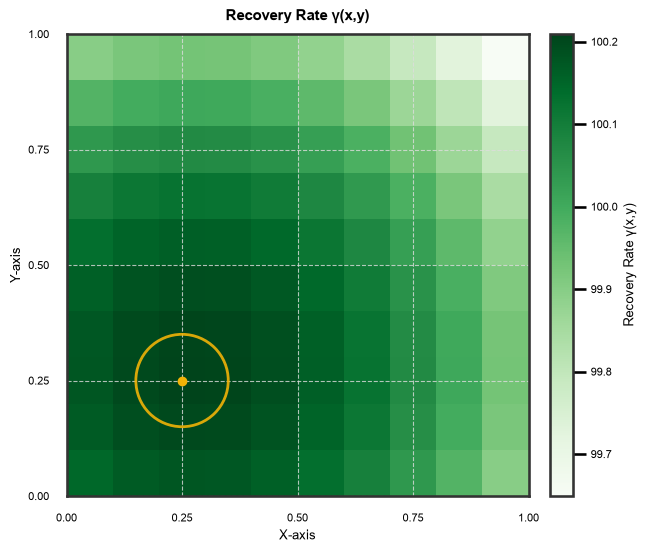

In [8]:
# ploting heatmaps of beta and gamma
output_dir = Path.cwd().parent / "outputs" / "figures" / "nb1"
output_dir.mkdir(parents=True, exist_ok=True)

fig_beta, ax_beta, _ = plot_heatmap(
    beta_field,
    title='Transmission Rate β(x,y)',
    xlabel='X-axis',
    ylabel='Y-axis',
    cmap='Blues',
    center=C_BETA,
    radius=R_BETA,
    circle_edgecolor="#04CF7B"
)
fig_beta.savefig(output_dir / "beta_field.png", dpi=200, bbox_inches='tight')

fig_gamma, ax_gamma, _ = plot_heatmap(
    gamma_field,
    title='Recovery Rate γ(x,y)',
    xlabel='X-axis',
    ylabel='Y-axis',
    cmap='Greens',
    center=C_GAMMA,
    radius=R_GAMMA,
    circle_edgecolor="#F1B307"
)
fig_gamma.savefig(output_dir / "gamma_field.png", dpi=200, bbox_inches='tight')
